# Imports

In [17]:
#Add your packages here.
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


# Task 1

## a) 
Task: Get some jokes and print their type, steup and the punchline.

API: https://official-joke-api.appspot.com/

In [5]:
url = "https://official-joke-api.appspot.com/jokes/ten"

resp = requests.get(url, timeout=20)
resp.raise_for_status()

jokes = resp.json()

for i, joke in enumerate(jokes, 1):
    print(f"{i}. [{joke['type']}]")
    print("   Setup:     ", joke["setup"])
    print("   Punchline: ", joke["punchline"])
    print()
    

1. [general]
   Setup:      Is there a hole in your shoe?
   Punchline:  No… Then how’d you get your foot in it?

2. [general]
   Setup:      Why didn’t the orange win the race?
   Punchline:  It ran out of juice.

3. [programming]
   Setup:      Why do Java programmers wear glasses?
   Punchline:  Because they don't C#.

4. [general]
   Setup:      What do you call a fat psychic?
   Punchline:  A four-chin teller.

5. [general]
   Setup:      What do you call a droid that takes the long way around?
   Punchline:  R2 detour.

6. [programming]
   Setup:      Hey, wanna hear a joke?
   Punchline:  Parsing HTML with regex.

7. [general]
   Setup:      What do you call a singing Laptop?
   Punchline:  A Dell

8. [general]
   Setup:      What did the late tomato say to the early tomato?
   Punchline:  I’ll ketch up

9. [general]
   Setup:      What did the judge say to the dentist?
   Punchline:  Do you swear to pull the tooth, the whole tooth and nothing but the tooth?

10. [general]
   Se

## b) 

Task: Select a few users from Github and fetch their repos. Display name of repo, URL, description, stars, etc.

API: https://api.github.com/

In [7]:
# 1) Users auswählen
users = ["torvalds", "octocat", "pallets"]

all_repos = []

# Optional: GitHub Token (vermeidet Rate Limit)
headers = {}
token = os.getenv("GITHUB_TOKEN")
if token:
    headers["Authorization"] = f"Bearer {token}"

# 2) Für jeden User Repos holen
for user in users:
    url = f"https://api.github.com/users/{user}/repos"
    
    resp = requests.get(url, headers=headers, timeout=20)
    resp.raise_for_status()
    
    repos = resp.json()
    
    for r in repos:
        all_repos.append({
            "user": user,
            "repo_name": r.get("name"),
            "url": r.get("html_url"),
            "description": r.get("description"),
            "language": r.get("language"),
            "stars": r.get("stargazers_count"),
            "forks": r.get("forks_count"),
        })

# 3) DataFrame erstellen
df = pd.DataFrame(all_repos)

# Nach Stars sortieren
df = df.sort_values("stars", ascending=False).reset_index(drop=True)

df.head(20)

,user,repo_name,url,description,language,stars,forks
0,torvalds,linux,https://github.com/torvalds/linux,Linux kernel source tree,C,218447,60582
1,pallets,flask,https://github.com/pallets/flask,The Python micro framework for building web ap...,Python,71251,16730
2,pallets,click,https://github.com/pallets/click,Python composable command line interface toolkit,Python,17315,1573
3,octocat,Spoon-Knife,https://github.com/octocat/Spoon-Knife,This repo is for demonstration purposes only.,HTML,13623,156359
4,pallets,jinja,https://github.com/pallets/jinja,A very fast and expressive template engine.,Python,11478,1704
5,pallets,werkzeug,https://github.com/pallets/werkzeug,The comprehensive WSGI web application library.,Python,6848,1762
6,torvalds,AudioNoise,https://github.com/torvalds/AudioNoise,Random digital audio effects,C,4242,196
7,pallets,quart,https://github.com/pallets/quart,An async Python micro framework for building w...,Python,3600,193
8,octocat,Hello-World,https://github.com/octocat/Hello-World,My first repository on GitHub!,None,3515,5870
9,pallets,itsdangerous,https://github.com/pallets/itsdangerous,Safely pass trusted data to untrusted environm...,Python,3103,233


# Task 2

## a)

Task: Retrieve data on recent (1 month) earthquakes worldwide and visualize 
 - their magnitude distribution
 - frequencies

API: USGS Earthquake API (https://earthquake.usgs.gov/fdsnws/event/1/)

Number of earthquakes: 9356


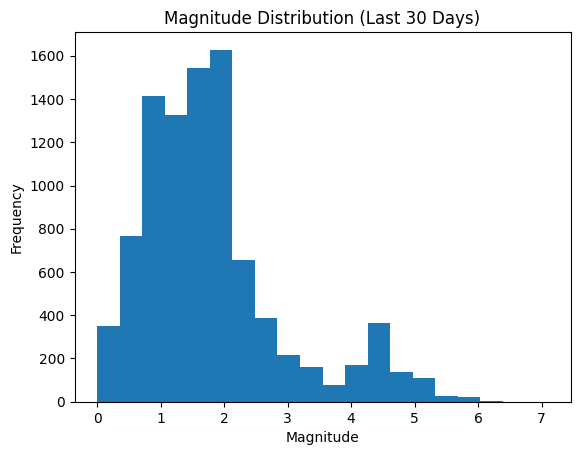

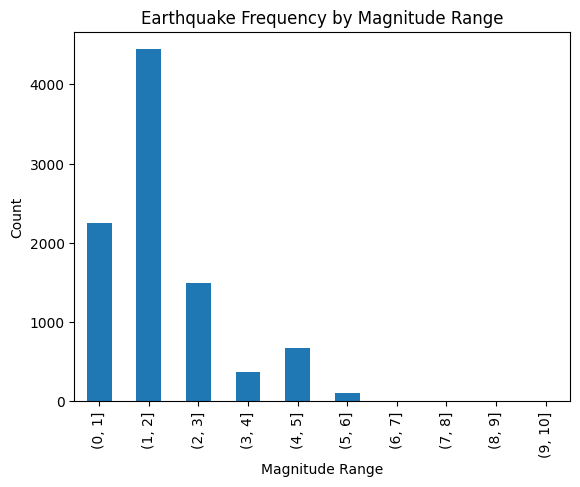

In [8]:
# 1) Zeitraum: letzter Monat
end = datetime.utcnow()
start = end - timedelta(days=30)

# 2) API Call
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
params = {
    "format": "geojson",
    "starttime": start.strftime("%Y-%m-%d"),
    "endtime": end.strftime("%Y-%m-%d"),
    "minmagnitude": 0
}

resp = requests.get(url, params=params, timeout=30)
resp.raise_for_status()
data = resp.json()

# 3) Magnitudes extrahieren
magnitudes = []
for feature in data["features"]:
    mag = feature["properties"]["mag"]
    if mag is not None:
        magnitudes.append(mag)

df = pd.DataFrame({"magnitude": magnitudes})

print("Number of earthquakes:", len(df))

# 4) Histogram (Magnitude Distribution)
plt.figure()
plt.hist(df["magnitude"], bins=20)
plt.title("Magnitude Distribution (Last 30 Days)")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

# 5) Frequencies pro Magnitude-Bereich
bins = [0,1,2,3,4,5,6,7,8,9,10]
df["mag_range"] = pd.cut(df["magnitude"], bins=bins)

freq = df["mag_range"].value_counts().sort_index()

plt.figure()
freq.plot(kind="bar")
plt.title("Earthquake Frequency by Magnitude Range")
plt.xlabel("Magnitude Range")
plt.ylabel("Count")
plt.show()

## b)

Task: Select some locations and plot them on a map along with the earthquake magnitude for a particular day.

API: USGS Earthquake API (https://earthquake.usgs.gov/fdsnws/event/1/)

Check out: Plotly, Basemap, etc. packages

In [9]:
# 1) Datum wählen: gestern (UTC)
day = (datetime.utcnow() - timedelta(days=1)).date()
starttime = day.isoformat()
endtime = (day + timedelta(days=1)).isoformat()

# 2) USGS API Call (für einen Tag)
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
params = {
    "format": "geojson",
    "starttime": starttime,
    "endtime": endtime,
    "minmagnitude": 2.5  
}

resp = requests.get(url, params=params, timeout=30)
resp.raise_for_status()
data = resp.json()

# 3) Daten extrahieren: Ort + Magnitude + Koordinaten
rows = []
for f in data["features"]:
    props = f["properties"]
    coords = f["geometry"]["coordinates"]  # [lon, lat, depth]
    mag = props.get("mag")
    place = props.get("place")

    if mag is None or coords is None:
        continue

    lon, lat, depth = coords
    rows.append({
        "time": pd.to_datetime(props["time"], unit="ms"),
        "place": place,
        "mag": mag,
        "lon": lon,
        "lat": lat,
        "depth_km": depth
    })

df = pd.DataFrame(rows)
print("Date:", starttime, "| Number of earthquakes:", len(df))
df.head()

Date: 2026-02-22 | Number of earthquakes: 39


,time,place,mag,lon,lat,depth_km
0,2026-02-22 22:36:17.004,"60 km WNW of Pisco, Peru",5.30,-76.738500,-13.558100,35.0
1,2026-02-22 22:05:12.578,"Kepulauan Babar, Indonesia",4.50,129.793400,-7.977900,10.0
2,2026-02-22 19:11:25.964,"55 km SE of Mohr, Iran",4.20,53.252600,27.175800,10.0
3,2026-02-22 18:25:02.540,"46 km SW of Kekaha, Hawaii",4.14,-160.044833,21.687167,11.4
4,2026-02-22 18:03:32.888,"86 km SSW of San Juan, Peru",4.40,-75.345100,-16.123600,10.0


# Task 3

Task: Check out the free stock market API and prepare some interesting plots of your own. (ex: compare highs and lows per day over a timeperiod for Apple and IBM)

API: https://www.alphavantage.co/  (Requires Key)

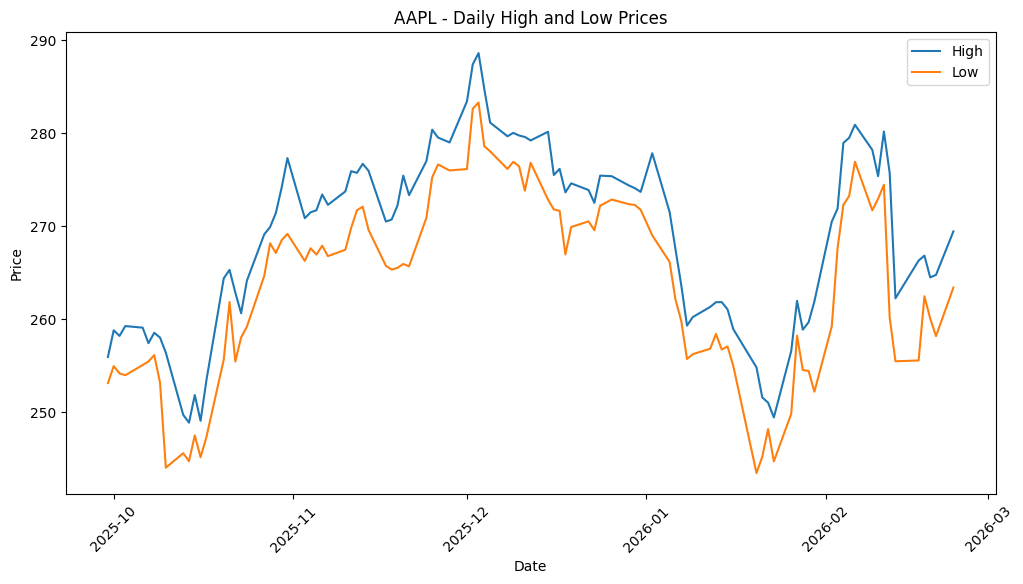

In [18]:
API_KEY = "DEIN_KEY"

def get_stock(symbol):
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": symbol,
        "apikey": API_KEY,
        "outputsize": "compact"
    }
    
    r = requests.get(url, params=params)
    data = r.json()
    
    if "Time Series (Daily)" not in data:
        print("API Problem:", data)
        return None
    
    df = pd.DataFrame.from_dict(data["Time Series (Daily)"], orient="index")
    
    df = df.rename(columns={
        "1. open": "open",
        "2. high": "high",
        "3. low": "low",
        "4. close": "close",
        "5. volume": "volume"
    })
    
    df = df.astype(float)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    
    return df


aapl = get_stock("AAPL")

plt.figure(figsize=(12,6))
plt.plot(aapl.index, aapl["high"], label="High")
plt.plot(aapl.index, aapl["low"], label="Low")
plt.title("AAPL - Daily High and Low Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()